In [1]:
import torch
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline
from test_runner import run_tests
from ImageObjects import ImageObject, MaskObject
from masks import create_focus_mask, create_not_focus_mask, create_stochastic_mask

In [2]:
lemon_image = Image.open("lemon.png").convert("RGB").resize((512, 512))
prompt_repare = "a cut lemon on a dark reflective surface"
prompt_repaint1 = "a cut orange on a dark reflective surface"
prompt_repaint2 = "a cut apple on a dark reflective surface"
prompt_repaint3 = "a spaceship in the space"
prompts = ["",prompt_repare,prompt_repaint1,prompt_repaint2,prompt_repaint3]
lemonObject = ImageObject("lemon",lemon_image,prompts,220,220)



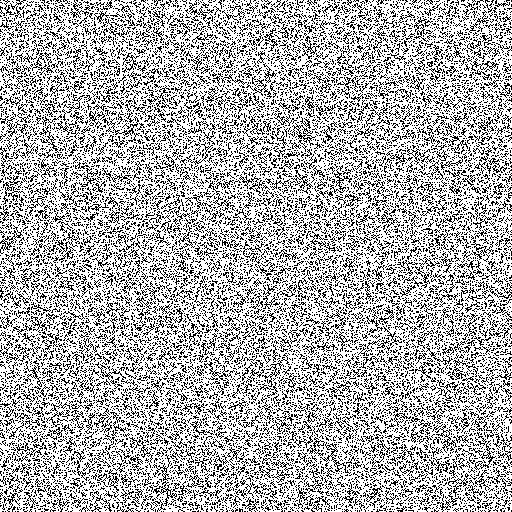

In [3]:
create_stochastic_mask(0.3)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "../1/stable-diffusion-2-base"

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: ../1/stable-diffusion-2-base/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


StableDiffusionInpaintPipeline {
  "_class_name": "StableDiffusionInpaintPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "../1/stable-diffusion-2-base",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [8]:
masks = []

for k in range(1,5):
    mask_image = create_focus_mask(lemonObject.center_x, lemonObject.center_y, 2**-k)
    mask_name=f"focus_{k}"
    masks.append(MaskObject(mask_name, mask_image))
    
for k in range(1,5):
    mask_image = create_not_focus_mask(lemonObject.center_x, lemonObject.center_y, 2**-k)
    mask_name=f"not_focus_{k}"
    masks.append(MaskObject(mask_name, mask_image))



In [9]:
run_tests(masks,[lemonObject], pipe)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [5]:
masks = []

for k in range(1,4):
    for i in range(0,1):
        mask_image = create_stochastic_mask(0.25*k)
        mask_name=f"stochatic_{k*25}%_{i}"
        masks.append(MaskObject(mask_name, mask_image))


In [6]:
run_tests(masks,[lemonObject], pipe)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]